<h2 style="font-weight:600;color:#7fba94">Nigerian Music scraped from Spotify - an analysis</h2>

<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">1 | Cluster your Data</h3>

Load a dataframe with some data of Nigerian music and print out the first five records.

In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

df = pd.read_csv("../data/nigerian-songs.csv")
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4


Get some information about the dataframe:

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              530 non-null    str    
 1   album             530 non-null    str    
 2   artist            530 non-null    str    
 3   artist_top_genre  530 non-null    str    
 4   release_date      530 non-null    int64  
 5   length            530 non-null    int64  
 6   popularity        530 non-null    int64  
 7   danceability      530 non-null    float64
 8   acousticness      530 non-null    float64
 9   energy            530 non-null    float64
 10  instrumentalness  530 non-null    float64
 11  liveness          530 non-null    float64
 12  loudness          530 non-null    float64
 13  speechiness       530 non-null    float64
 14  tempo             530 non-null    float64
 15  time_signature    530 non-null    int64  
dtypes: float64(8), int64(4), str(4)
memory usage: 66.4 KB


Check for null values, verifying that the sum is 0:

In [75]:
df.isnull().sum()

name                0
album               0
artist              0
artist_top_genre    0
release_date        0
length              0
popularity          0
danceability        0
acousticness        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
time_signature      0
dtype: int64

Describe the data:

In [76]:
df.describe()

,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
count,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000
mean,2015.390566,222298.169811,17.507547,0.741619,0.265412,0.760623,0.016305,0.147308,-4.953011,0.130748,116.487864,3.986792
std,3.131688,39696.822259,18.992212,0.117522,0.208342,0.148533,0.090321,0.123588,2.464186,0.092939,23.518601,0.333701
min,1998.000000,89488.000000,0.000000,0.255000,0.000665,0.111000,0.000000,0.028300,-19.362000,0.027800,61.695000,3.000000
25%,2014.000000,199305.000000,0.000000,0.681000,0.089525,0.669000,0.000000,0.075650,-6.298750,0.059100,102.961250,4.000000
50%,2016.000000,218509.000000,13.000000,0.761000,0.220500,0.784500,0.000004,0.103500,-4.558500,0.097950,112.714500,4.000000
75%,2017.000000,242098.500000,31.000000,0.829500,0.403000,0.875750,0.000234,0.164000,-3.331000,0.177000,125.039250,4.000000
max,2020.000000,511738.000000,73.000000,0.966000,0.954000,0.995000,0.910000,0.811000,0.582000,0.514000,206.007000,5.000000


Use a barplot to find out the most popular genres:

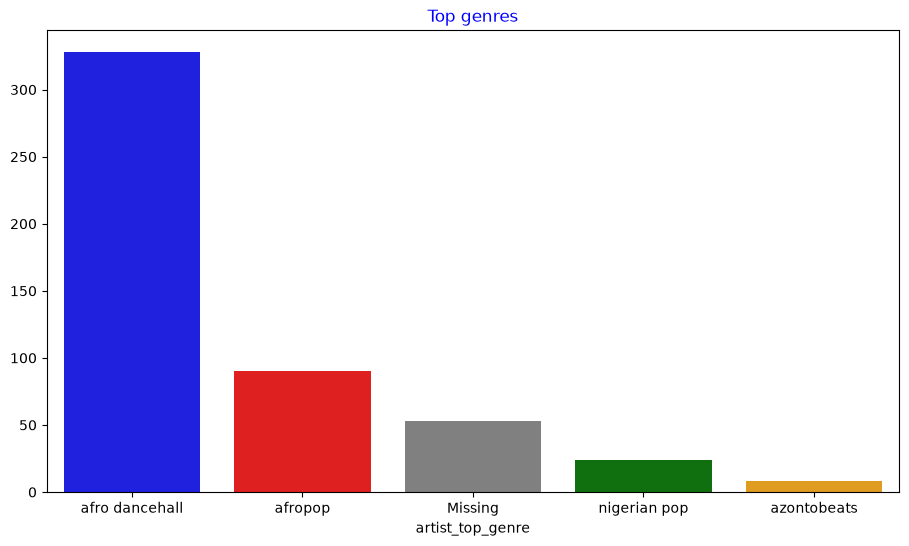

In [77]:
top = df["artist_top_genre"].value_counts()
plt.figure(figsize=(11, 6))
colors = ["blue", "red", "gray", "green", "orange"]
sns.barplot(x=top[:5].index, y=top[:5].values, palette=colors)
plt.xticks(rotation=0)
plt.title("Top genres", color="blue")

plt.show()

Get rid of missing data by filtering it out:

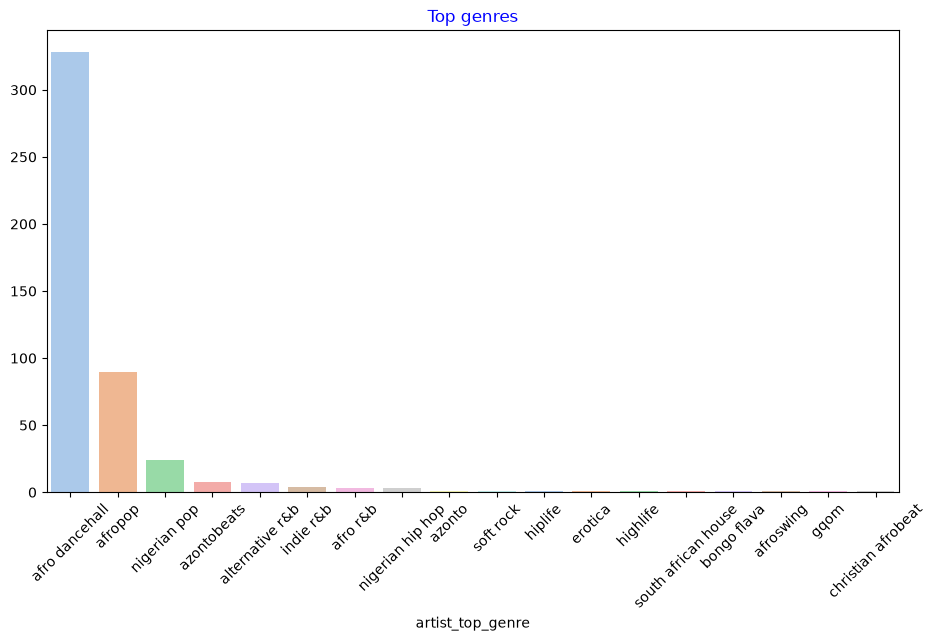

In [78]:
df = df[df["artist_top_genre"] != "Missing"]

top = df["artist_top_genre"].value_counts()
plt.figure(figsize=(11, 6))
colors = ["blue", "red", "green", "gray", "orange"]
sns.barplot(x=top.index, y=top.values, palette="pastel")
plt.xticks(rotation=45)
plt.title("Top genres", color="blue")

plt.show()

Let's concentrate on the top 3 genres i.e. `afro dancehall`, `afropop` and `nigerian pop`.<br/>
Also, remove anything with 0 popularity: it is considered as **noise** for our purposes:

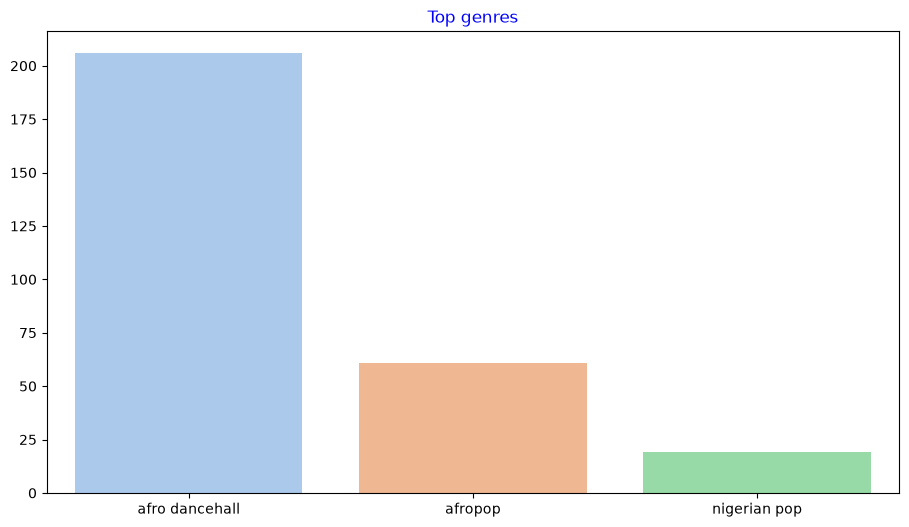

In [82]:
df = df[
    (df["artist_top_genre"] == "afro dancehall")
    | (df["artist_top_genre"] == "afropop")
    | (df["artist_top_genre"] == "nigerian pop")
]
df = df[df["popularity"] > 0]

top = df["artist_top_genre"].value_counts()
plt.figure(figsize=(11, 6))
sns.barplot(x=top.index, y=top.values, palette="pastel")
plt.xticks(rotation=0)
plt.xlabel("")
plt.title("Top genres", color="blue")

plt.show()

Do a quick test to see if the data correlates in any particular strong way:

<Axes: >

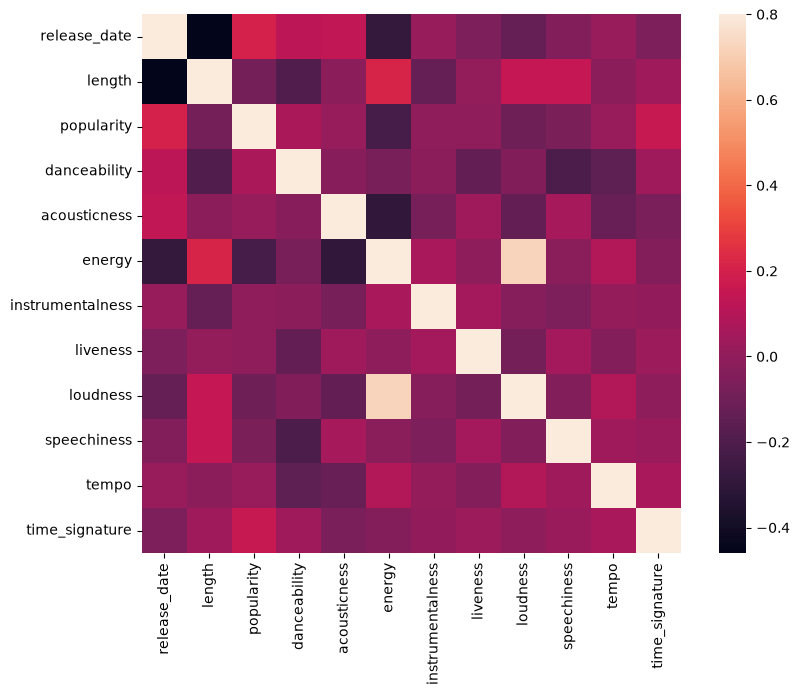

In [85]:
corrmat = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corrmat, vmax=0.8, square=True)

The only strong correlation is between `energy` and `loudness`, which is not surprizing since loud music is usually quite energetic!

The rest of the correlations are pretty weak.

<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">2 | Data Distribution</h3>

Are the three genres significantly different in their perception of their danceability, based on their popularity?

Examine the top three genres data distribution for popularity and danceability along a given x and y axis.

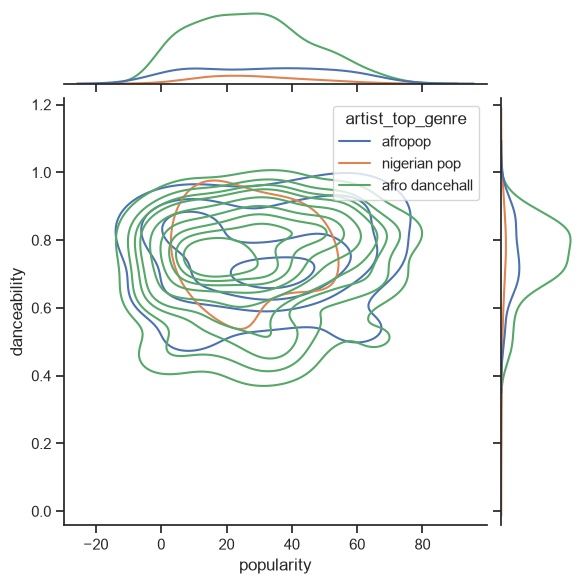

In [86]:
sns.set_theme(style="ticks")

g = sns.jointplot(
    data=df,
    x="popularity",
    y="danceability",
    hue="artist_top_genre",
    kind="kde",
)

The three genres align loosely in terms of their popularity and danceability. Determining clusters will be a challenge!

Now create a scatter plot:

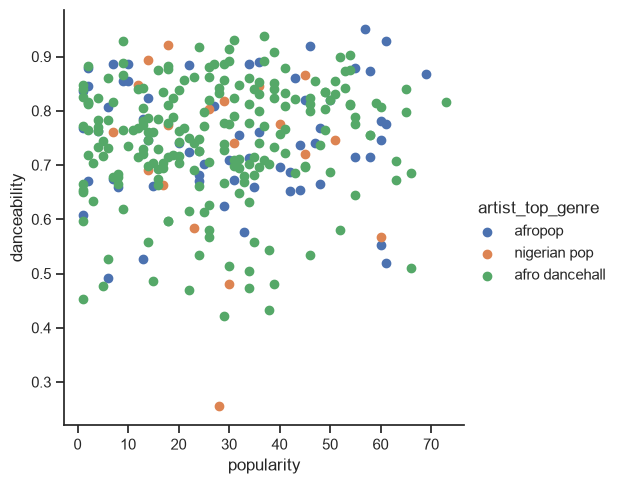

In [88]:
g = sns.FacetGrid(df, hue="artist_top_genre", height=5)
g.map(plt.scatter, "popularity", "danceability")
g.add_legend()

<h3 style="font-weight:600;color:white;background:#7fba94;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">3 | References</h3>

1. [8 Clustering Algorithms in Machine Learning that All Data Scientists Should Know](https://www.freecodecamp.org/news/8-clustering-algorithms-in-machine-learning-that-all-data-scientists-should-know/)
2. [HDBSCAN Understanding Density-based Clustering](https://www.kdnuggets.com/2020/02/understanding-density-based-clustering.html)
3. [Transduction - machine learning](https://en.wikipedia.org/wiki/Transduction_(machine_learning))